**TÍTULO**

F2V — Validação independente in situ

**Projeto:** NINO-BRASIL — Oceanografia Física — UFPE  
**Código canônico:** `F2V`  
**Objeto de estudo:** processo físico definido para esta etapa do projeto  
**Família de hipótese:** `HIP0`

**CONTEXTO**

A validação in situ é independente do master semanal: CTD/WOD, TAO/TRITON e Argo não preenchem lacunas. O notebook compara observações com os campos diários UFS+GLORYS antes da agregação W-SUN e declara diferenças de representatividade espacial, temporal e instrumental.

**PERGUNTA CIENTÍFICA**

UFS+GLORYS reproduz a variabilidade do ORAS5 e apresenta diferenças sistemáticas quando comparado a CTD/WOD, TAO/TRITON e Argo?

**MOTIVAÇÃO**

*Hipótese específica*

A hipótese nula in situ é que o resíduo médio UFS+GLORYS menos observação é centrado em zero; a comparação de reanálises testa se as anomalias mensais UFS+GLORYS e ORAS5 não apresentam correlação diferente de zero.

A hipótese poderá ser sustentada, parcialmente sustentada ou rejeitada; a execução do notebook não antecipa o resultado.

*Função dos testes e unidade de análise*

A contagem de arquivos não demonstra validade física. O pareamento observação–reanálise e a agregação por perfil evitam tratar várias profundidades correlacionadas como réplicas independentes.

**METODOLOGIA**

Comparação mensal UFS+GLORYS–ORAS5 com correlações em nível e anomalias sem sazonalidade; pareamento in situ por dia, nó e profundidade; viés, MAE, RMSE, IC95%, tamanho amostral efetivo e FDR BH.

**RESULTADOS ESPERADOS**

Resultados esperados significam produtos necessários para responder à pergunta, não valores ou significâncias presumidos:

- inventário e cobertura de CTD/WOD, TAO/TRITON e Argo.
- tabela de resíduos por perfil ou boia-dia.
- viés, MAE, RMSE, correlação e intervalo bootstrap por fonte e variável.
- conclusão sobre diferença sistemática com correção FDR BH.
- séries mensais sobrepostas e correlações UFS+GLORYS–ORAS5 por variável e segmento de fonte.

- figuras públicas iniciadas por `FigF2V`;
- tabelas públicas iniciadas por `TabF2V`;
- primeiro par reservado: `FigF2V1` ↔ `TabF2V1`;
- toda interpretação deve apontar para tabela, run_id, unidade, amostra e limitações.

*Fundamentação científica mínima*

As referências completas utilizadas estão na última célula do notebook.

**PREMISSAS DE VALIDADE E LIMITES DE INTERPRETAÇÃO**

- Toda conclusão deve nascer de uma tabela `Tab...` persistida antes da figura correspondente.
- A execução é determinística e usa somente entradas declaradas no inventário mostrado abaixo.
- Notebook executado não implica hipótese confirmada; gates científicos são exibidos como resultados.

In [1]:
from pathlib import Path
import os
import sys
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
NOTEBOOK_CODE = 'F2V'
MODE = os.environ.get('NINO26_NOTEBOOK_MODE', 'official')
RUN_PIPELINE = os.environ.get('NINO26_RUN_PIPELINE', '0') == '1'
if RUN_PIPELINE:
    raise RuntimeError('O núcleo numérico deve ser executado pelo runner da fase, antes do notebook.')
from nino_brasil.notebook_workflows import NotebookWorkflow
workflow = NotebookWorkflow(ROOT, NOTEBOOK_CODE, mode=MODE)
workflow.describe()

{
  "notebook_code": "F2V",
  "phase": 2,
  "enso_type": null,
  "mode": "official",
  "execution_policy": "numeric-core-first-viewer-publisher"
}


{'notebook_code': 'F2V',
 'phase': 2,
 'enso_type': None,
 'mode': 'official',
 'execution_policy': 'numeric-core-first-viewer-publisher'}

**DADOS**

In [2]:
input_inventory = workflow.input_inventory()
display(input_inventory)
workflow.require_inputs()

,role,path,required,exists,bytes
0,CTD/WOD em Zarr,data\processed\zarr\ctd_noaa\wod,True,True,NaN
1,TAO/TRITON em Zarr,data\processed\zarr\validation\tao_triton,False,True,NaN
2,Argo em Zarr,data\processed\zarr\validation\argo,False,True,NaN
3,residuos pareados por perfil,data\processed\parquet\statistics\phase2_insit...,True,True,2182448.0
4,resumo inferencial da validacao in situ,data\processed\parquet\statistics\phase2_insit...,True,True,2299.0
5,comparacao de fontes oceanicas,data\processed\parquet\statistics\phase2_ocean...,True,True,1548.0
6,series mensais pareadas UFS+GLORYS e ORAS5,data\processed\parquet\statistics\phase2_ufs_g...,True,True,779116.0
7,correlacoes e erros UFS+GLORYS versus ORAS5,data\processed\parquet\statistics\phase2_ufs_g...,True,True,16159.0


**RESULTADOS**

In [3]:
result = workflow.run()
display(result.artifacts)
display(result.summary)

,notebook_code,ordinal,namespace,figure_code,table_code,figure_path,table_path,manifest_path,figure_sha256,table_sha256,run_id
0,F2V,1,fase2,FigF2V1_inventario_validacao_insitu,TabF2V1_inventario_validacao_insitu,C:\DEV\NINO26\data\processed\figures\fase2\Fig...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\metadata\figure-t...,04ba9af3b73570164c8ad4bc51115f0dfa3641d4fbdb0d...,30b4be8e36ca213bc6799f1ef4b5123abd9925fb4063cb...,phase2_20260715T205936Z_64adc71c
1,F2V,2,fase2,FigF2V2_comparacao_pareada_significancia,TabF2V2_comparacao_pareada_significancia,C:\DEV\NINO26\data\processed\figures\fase2\Fig...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\metadata\figure-t...,f2a8e1e7e21abf4976eadbba95ba1e6d26aa1d0f687e46...,9c6e111d95f4115ac5ce97022922efc41918cbedfabd2c...,phase2_20260715T205936Z_64adc71c
2,F2V,3,fase2,FigF2V3_residuos_por_perfil,TabF2V3_residuos_por_perfil,C:\DEV\NINO26\data\processed\figures\fase2\Fig...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\metadata\figure-t...,bd54da60754307bf6e1b7cc55483e41a264909229c730b...,0e4d522fac87a3788c7ae40837f86297d4b96b81ebe8c1...,phase2_20260715T205936Z_64adc71c
3,F2V,4,fase2,FigF2V4_contrato_fontes_oceanicas,TabF2V4_contrato_fontes_oceanicas,C:\DEV\NINO26\data\processed\figures\fase2\Fig...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\metadata\figure-t...,e3d93727dff523453e5ca1a6471a3710dbbe55fb5ad63b...,c8d0b31c064713e19ea7caf9d82c33402d9fca51c97373...,phase2_20260715T205936Z_64adc71c
4,F2V,5,fase2,FigF2V5_series_mensais_ufs_glorys_oras,TabF2V5_series_mensais_ufs_glorys_oras,C:\DEV\NINO26\data\processed\figures\fase2\Fig...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\metadata\figure-t...,02be1b39d2a5990a710d31f11ea43c9b7d339289074d21...,35a014bd7db3d5922dc3ff5331f83eedf218e7547a98c6...,phase2_20260715T205936Z_64adc71c
5,F2V,6,fase2,FigF2V6_correlacoes_ufs_glorys_oras,TabF2V6_correlacoes_ufs_glorys_oras,C:\DEV\NINO26\data\processed\figures\fase2\Fig...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\metadata\figure-t...,d1cc20dc02cc94db74ece8f94a9442c4c83dd65d2f6ae7...,933abb7d7675499b061a3ce421df26fbfb3b82614407f8...,phase2_20260715T205936Z_64adc71c


,fonte_insitu,variavel,n_perfis_independentes,n_niveis_pareados,inicio,fim,bias_modelo_menos_insitu,bias_ic95_inf_bootstrap_perfil,bias_ic95_sup_bootstrap_perfil,mae_medio_perfil,rmse_medio_perfil,correlacao_entre_medias_de_perfil,p_wilcoxon_bias_zero,unidade,unidade_amostral_teste,q_fdr_bh,diferenca_significativa_fdr_05,conclusao
0,Argo,salinity,1393,212886,2026-01-01 01:44:03,2026-07-07 21:01:10,0.003440,0.001115,0.005870,0.071583,0.101680,0.969641,7.638933e-03,1e-3,perfil/boia-dia; profundidades agregadas antes...,7.638933e-03,True,vies_sistematico_detectado
1,Argo,temperature,1659,253556,2026-01-01 01:44:03,2026-07-07 21:01:10,0.342757,0.324328,0.360209,0.747853,1.260064,0.975887,2.423549e-182,degC,perfil/boia-dia; profundidades agregadas antes...,7.270648e-182,True,vies_sistematico_detectado
2,CTD/WOD,salinity,1958,113222,1981-07-13 00:00:00,2023-05-15 00:00:00,-0.008560,-0.010840,-0.006182,0.071879,0.109867,0.943358,3.476943e-19,1e-3,perfil/boia-dia; profundidades agregadas antes...,4.172332e-19,True,vies_sistematico_detectado
3,CTD/WOD,temperature,1958,113222,1981-07-13 00:00:00,2023-05-15 00:00:00,0.080508,0.063822,0.096769,0.579731,0.938562,0.983366,7.570739e-22,degC,perfil/boia-dia; profundidades agregadas antes...,1.135611e-21,True,vies_sistematico_detectado
4,TAO/TRITON,salinity,2117,7528,2026-01-01 12:00:00,2026-07-02 12:00:00,-0.030606,-0.036327,-0.024489,0.097914,0.103863,0.843675,4.175336e-29,1e-3,perfil/boia-dia; profundidades agregadas antes...,8.350672e-29,True,vies_sistematico_detectado
5,TAO/TRITON,temperature,2591,39544,2026-01-01 12:00:00,2026-07-02 12:00:00,0.238446,0.223894,0.254723,0.564675,0.950069,0.981717,4.942531e-185,degC,perfil/boia-dia; profundidades agregadas antes...,2.965518e-184,True,vies_sistematico_detectado


**FIGURAS PARA VERIFICAÇÃO RÁPIDA**

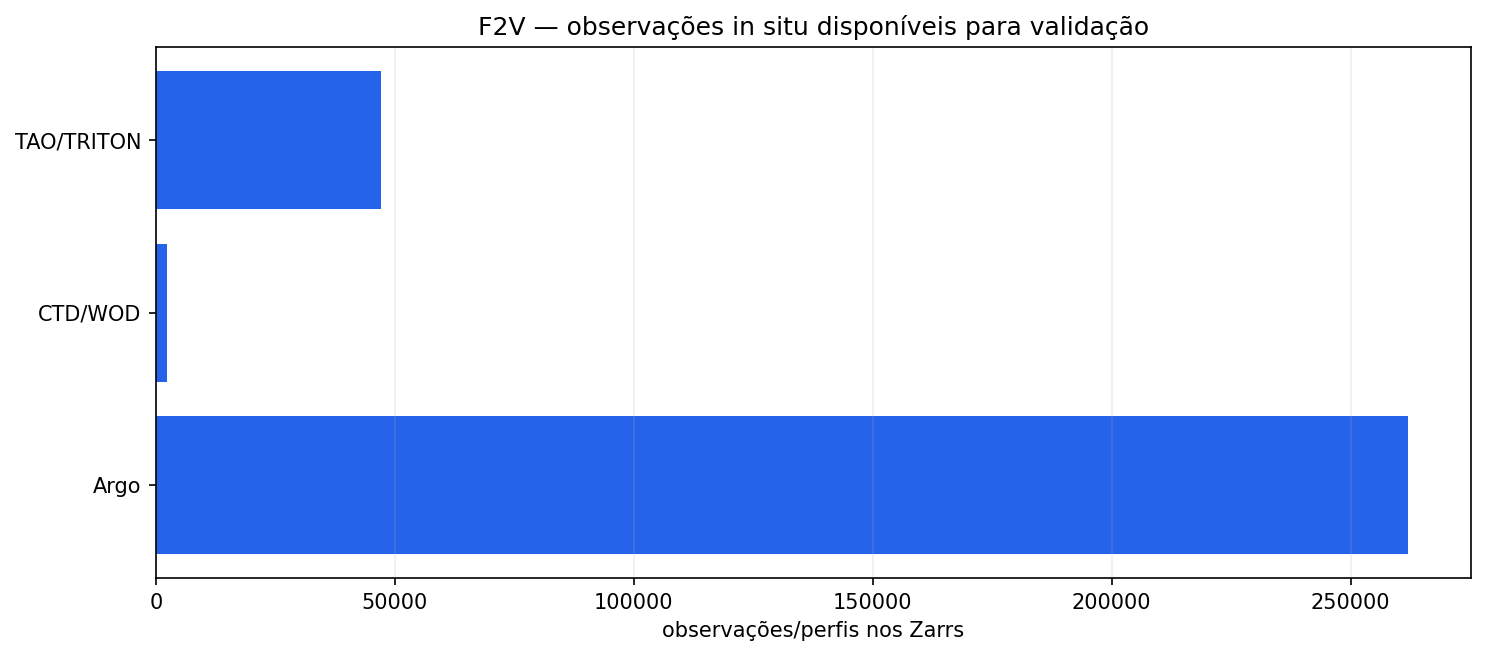

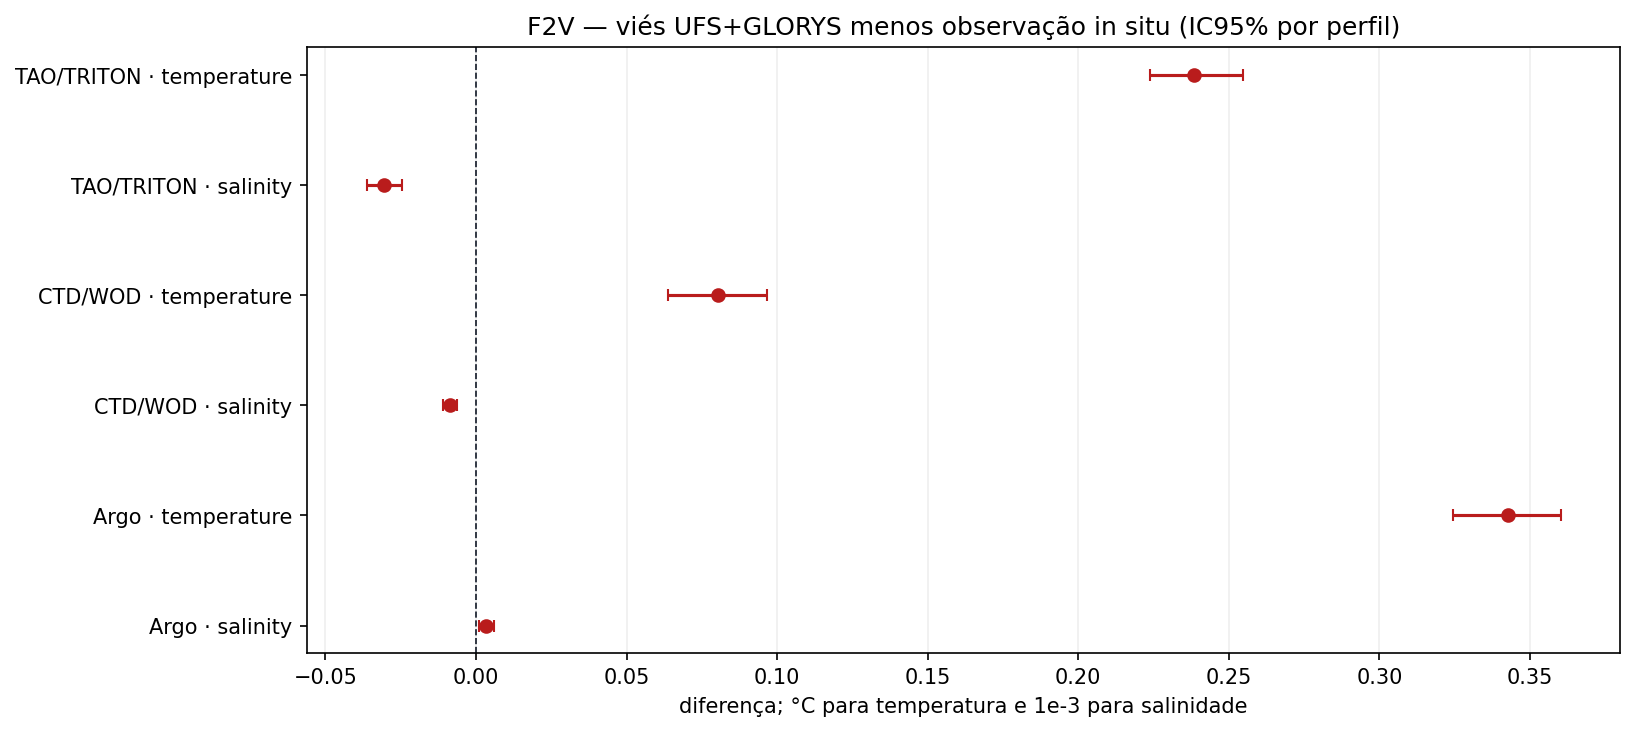

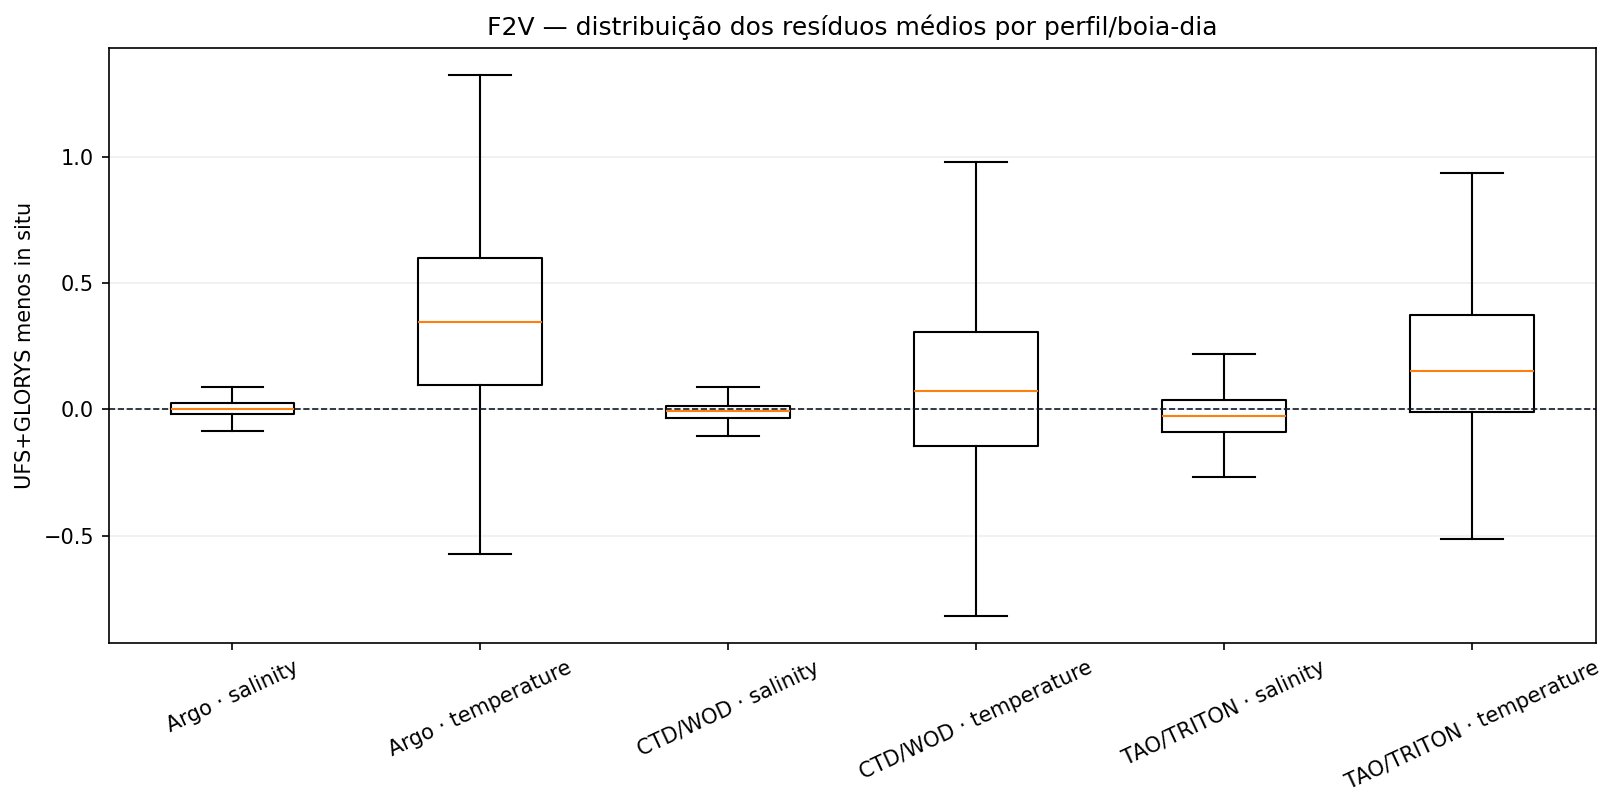

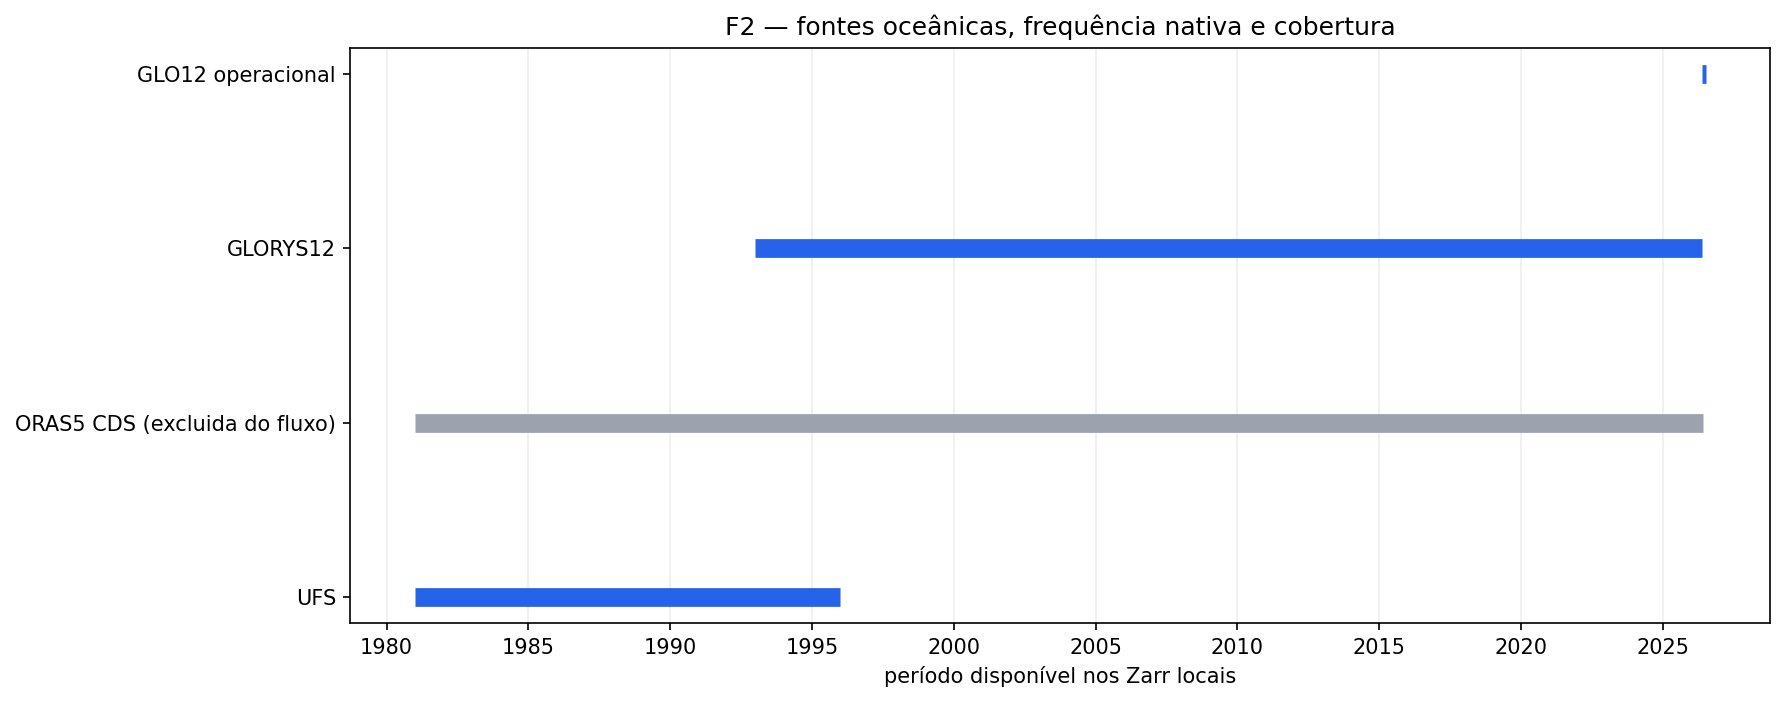

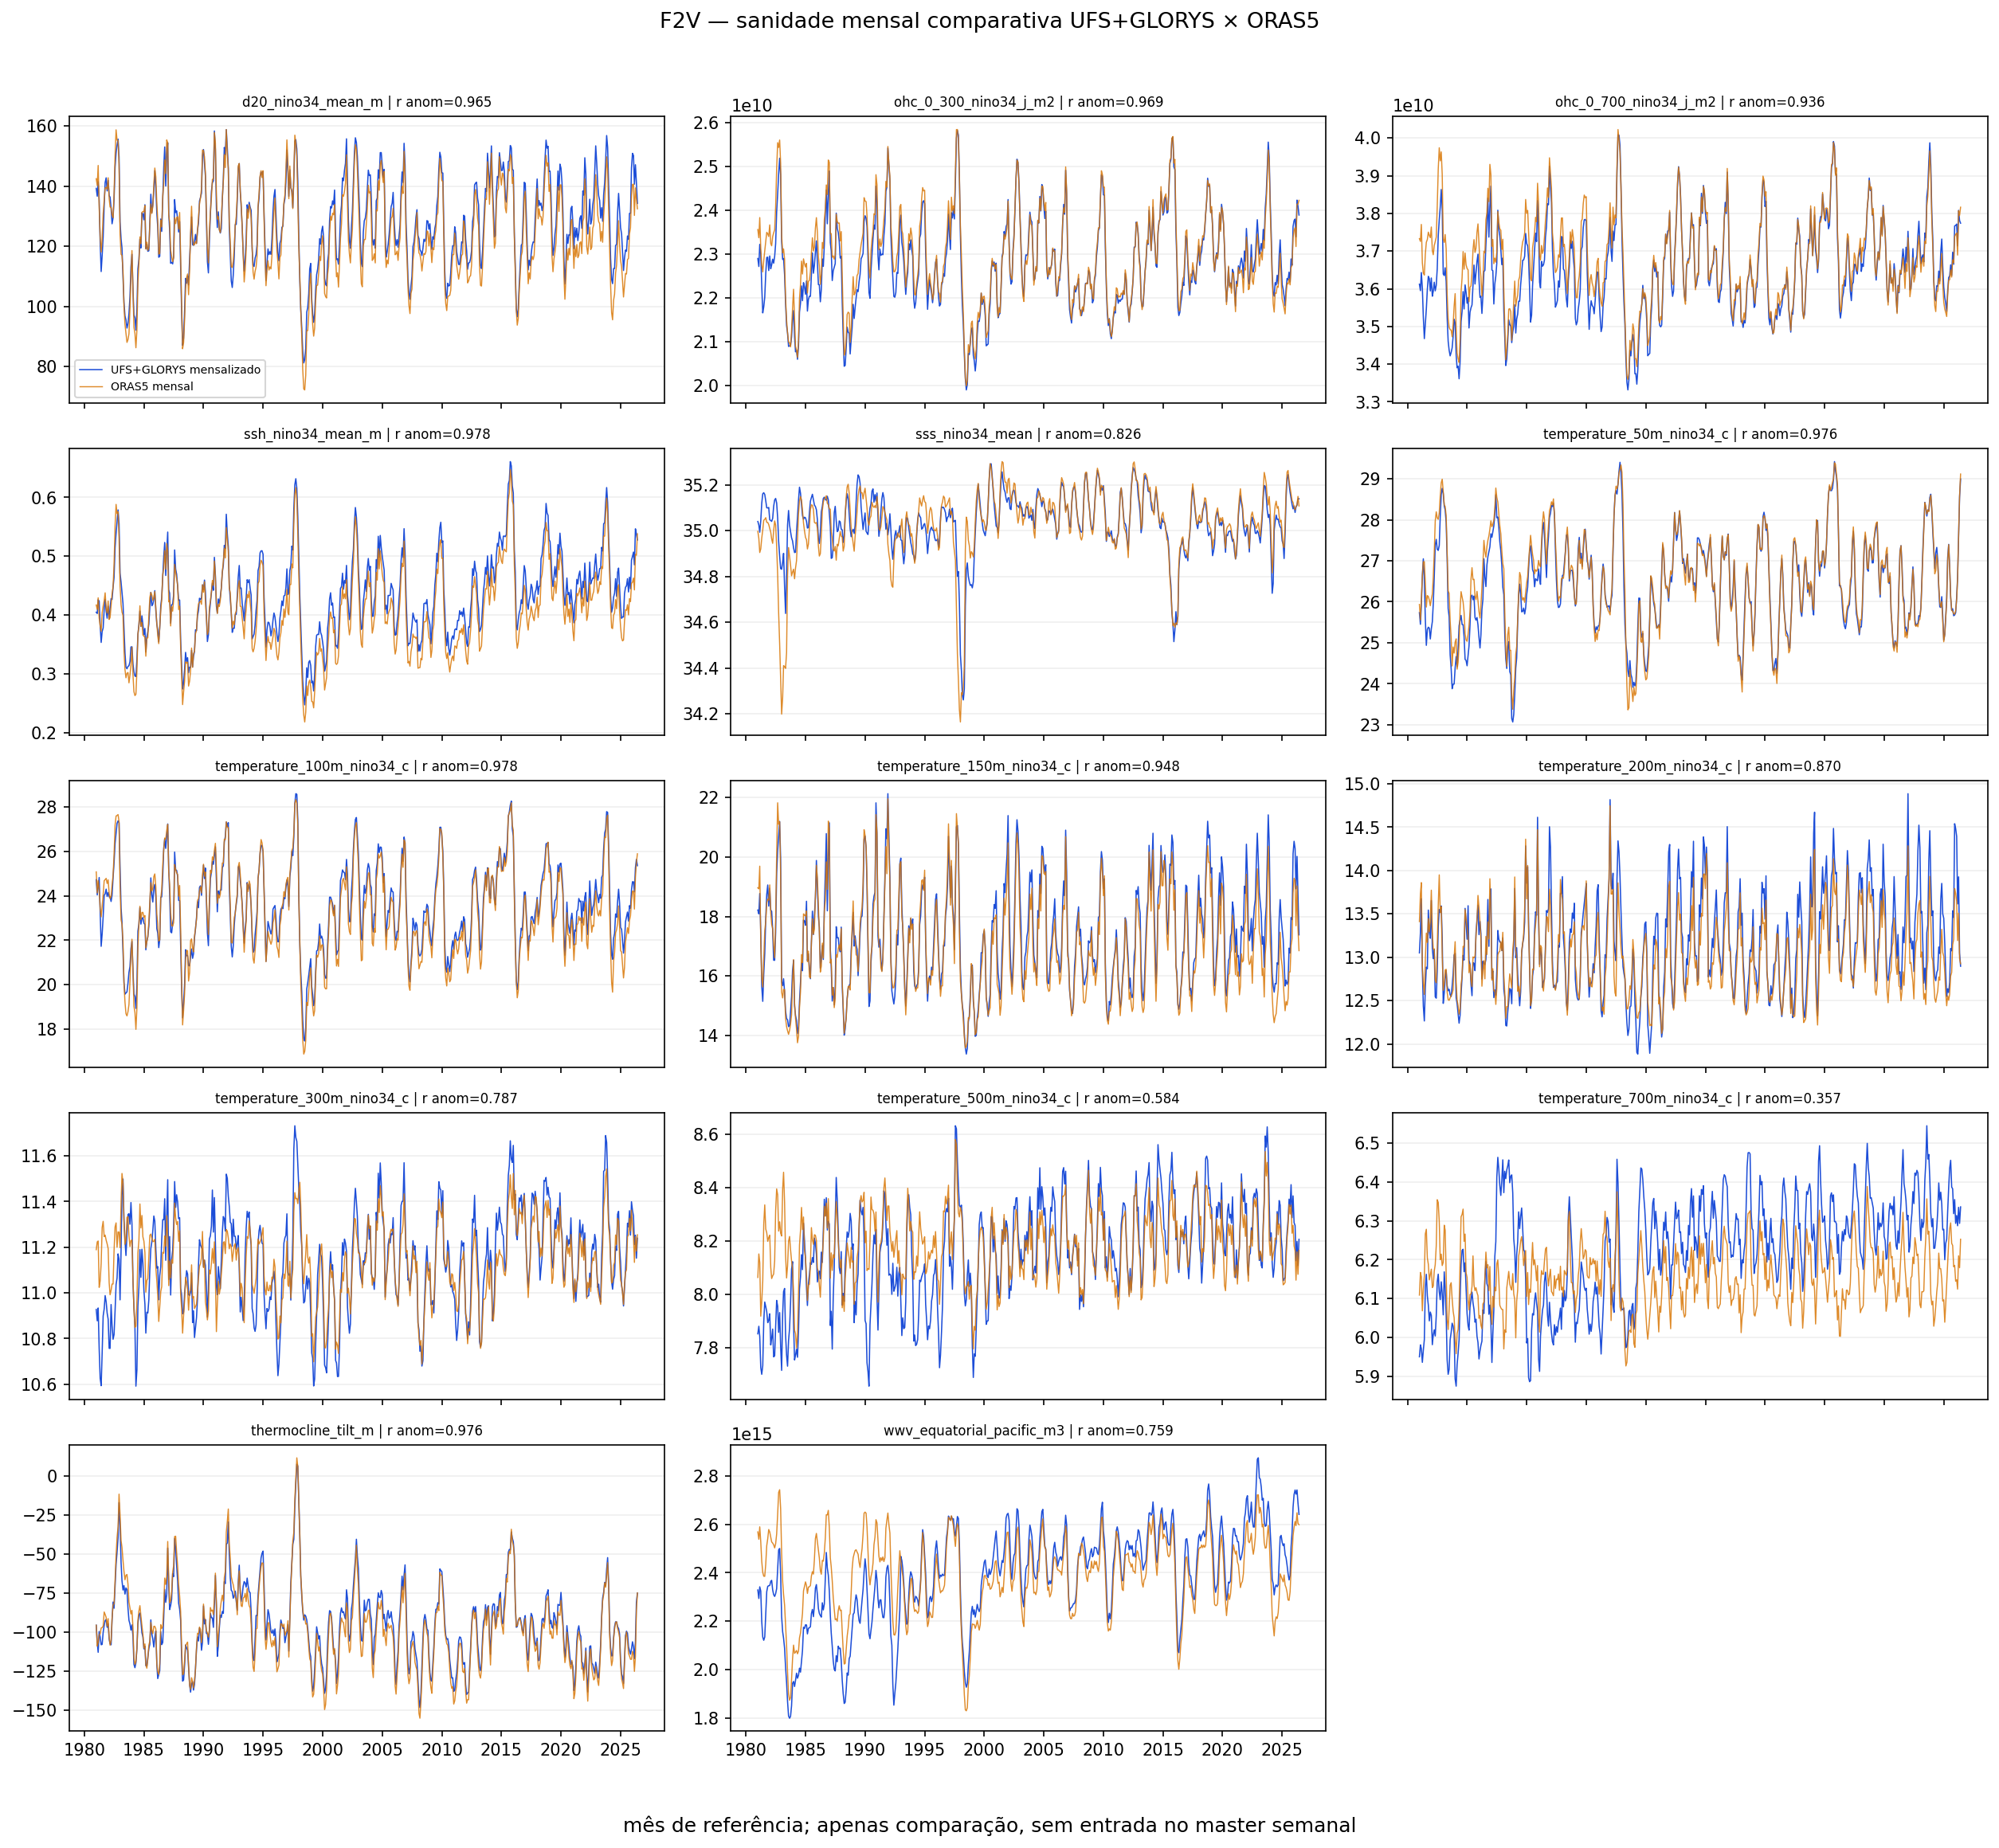

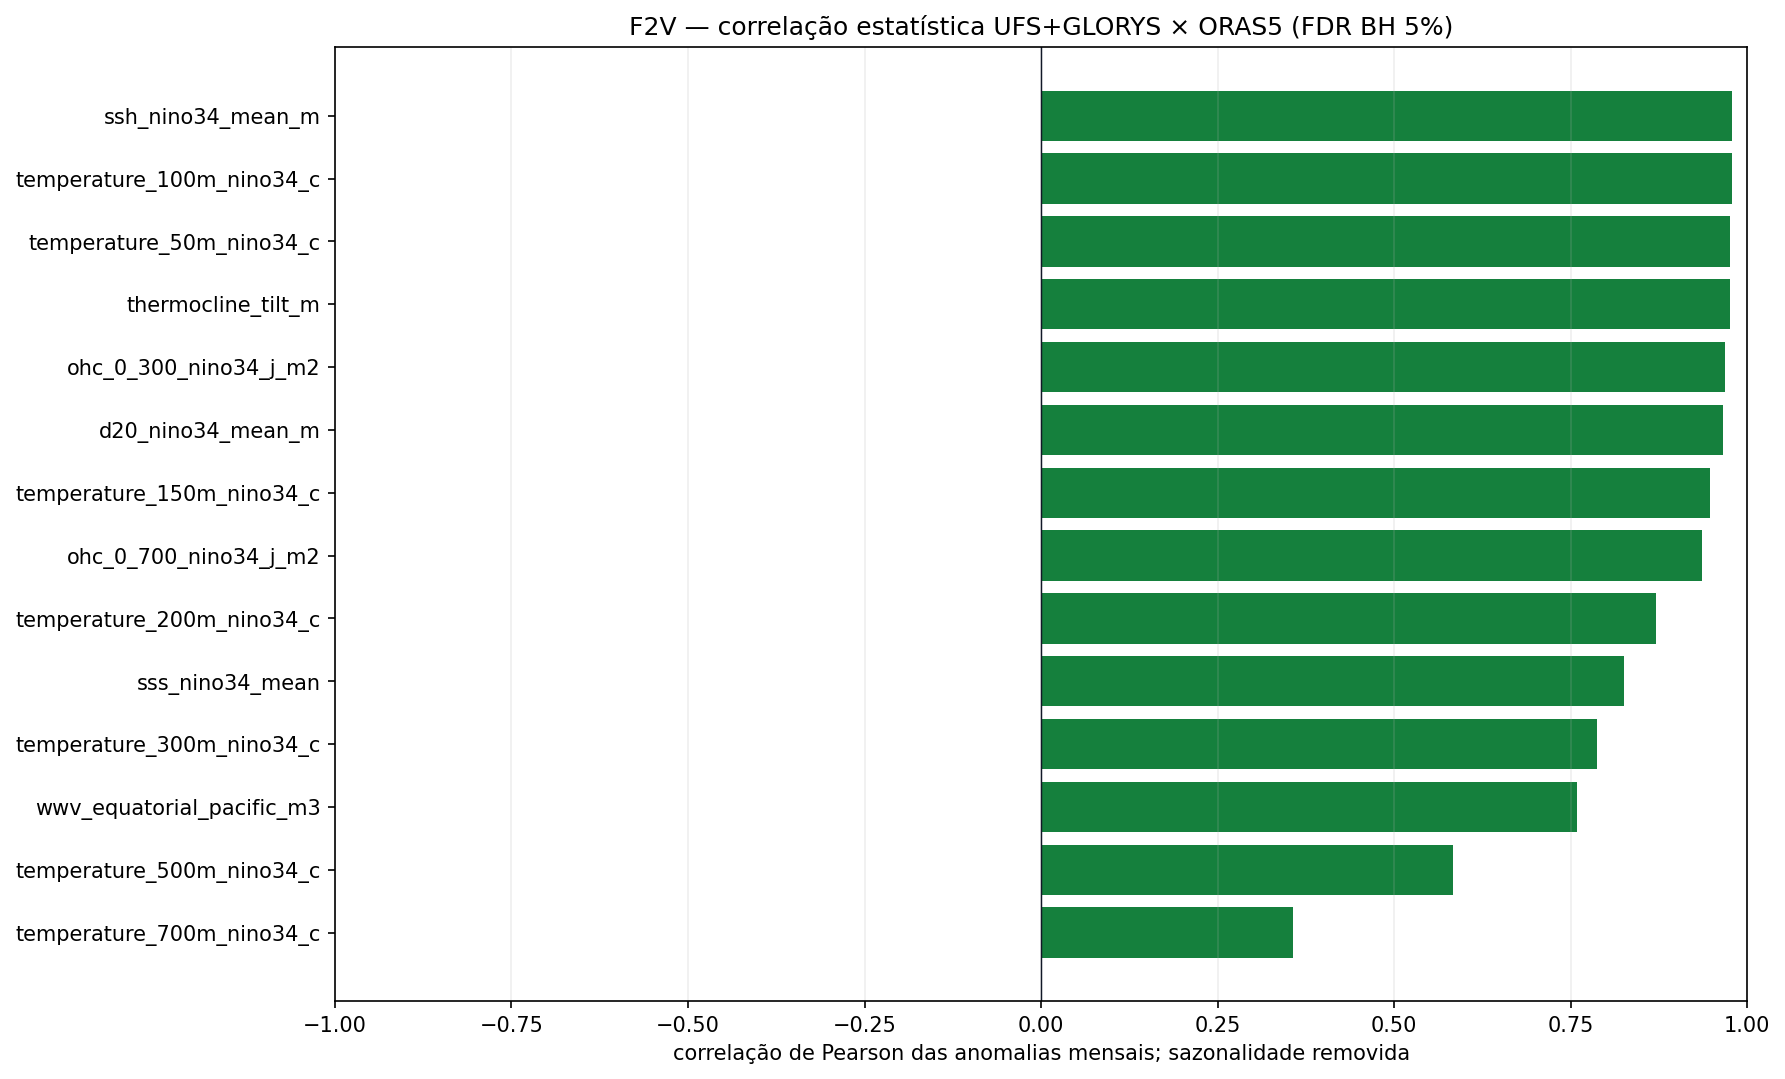

In [4]:
from IPython.display import Image, display

for artifact in result.artifacts.itertuples(index=False):
    display(Image(filename=str(artifact.figure_path)))

**CONCLUSÕES**

In [5]:
for item in result.takeaways:
    print(f'- {item}')
print('\nLimitações:')
for item in result.limitations:
    print(f'- {item}')

- As fontes in situ validam UFS+GLORYS e não preenchem lacunas da matriz principal.
- Cada observação é pareada ao dia, nó horizontal e profundidade mais próximos; o teste usa perfil/boia-dia, não cada profundidade como réplica independente.
- Foram avaliadas 6 combinações fonte–variável; 6 apresentaram viés diferente de zero após correção FDR BH a 5%.
- Diferença significativa indica viés sistemático detectável, não invalidação automática; magnitude, RMSE, correlação e adequação física devem ser examinadas conjuntamente.
- ORAS5 é média mensal comprovada: participa somente da comparação mensal independente e nunca da formação das semanas.
- A comparação UFS+GLORYS × ORAS5 publicou 42 testes de correlação por segmento e variável, com tamanho amostral efetivo e FDR BH explícitos.

Limitações:
- A aprovação vale para análise estatística semanal sem limpeza adicional; lacunas continuam explícitas na tabela de contrato.
- Em modelagem preditiva, qualquer climatologia ou ajuste deve ser est

**REFERÊNCIAS BIBLIOGRÁFICAS**

1. NINO-BRASIL. Documentação metodológica, contrato de dados e diretrizes da fase no repositório do projeto.